<a href="https://colab.research.google.com/github/zjuiEMLab/rshub/blob/main/demo/Snow-demo-DMRT-BIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Backscatter estimation using DMRT-TRI, NoSREx 2011.04.12 

In [ ]:
import datetime
import numpy as np
!pip install rshub==0.3.5 -q

In [12]:
# Define user token
# Register your account to get a token https://rshub.zju.edu.cn/Registration
token = 'YOUR_TOKEN_HERE' 
# Change your task name or project name every time you run a new job
project_name = 'CAS'
task_name = 'DMRT-TRI Active Demo'

In [13]:
# ============== CHANGE YOUR INPUT PARAMETERS HERE ==============
# ====== Parameters not define will be set to default values ======
# Step 1: Define Scenario flag
# 'soil': Bare soil
# 'snow': Snow
# 'veg': Vegetation covered soil
scenario_flag = 'snow'

# Step 2: Define observation description
# 1) Observation mode
# 'bs': Active (Backscatter)
# 'tb': Passive (Brightness temperature)
output_var = 'sigma'

# 2) Observation characteristics (GHz)
fGHz = [16.7]

angle=[30, 40, 50, 60] # Incident Angle (degree)
# angle = np.arange(0,70,5)
# angle = angle.tolist()


# Step 3: Define Algorithm flag
# 'qms': DMRT-QMS; 'bic': DMRT-BIC
algorithm = 'tri'

# Step 4: Define Ground Model parameters
Tg=273.2 # Ground Temperature [K]
clayfrac=0.3 #clay fraction

# Passive parameters to calculate surface backscattering
rough_model='OH'
rough_rms = 0.2 # rough ground rms height, (cm) rms == 0 assumes flat bottom boundary
rough_ratio = 7  # correlation length / rms height
surf_model_setting_active=[rough_model,rough_rms,rough_ratio] #'OH'


In [14]:
def load_snowpack_wet(filename):
    """
    Load snowpack description file.
    Each row describes one layer, from top to bottom.
    Each row contains seven numbers:
    layer_thickness (cm), density (gm/cc), Temperature (K),
    kc（zeta）, zp（b）, wet, film
    """
    try:
        data = np.loadtxt(filename)
    except OSError:
        raise ValueError("Could not open file")

        # Ensure data is a 2D array
    if data.ndim == 1:
        data = data.reshape(1, -1)  # Convert single row to (1, 6)

        # Check if the number of columns is correct
    if data.shape[1] != 7:
        raise ValueError(f"Expected 7 columns, but found {data.shape[1]}")

    depth = data[:, 0].tolist()
    rho = data[:, 1].tolist()
    Tsnow = data[:, 2].tolist()
    zp = data[:, 3].tolist()
    kc = data[:, 4].tolist()
    wet = data[:, 5].tolist()
    film = data[:, 6].tolist()

    return depth, rho, Tsnow, zp, kc, wet, film

## Run models

In [17]:
from rshub import submit_jobs
# Loop through different snowpack cases

CASE_TIMES = [
    "20101207_1000",
    "20110118_1400",
    "20110201_1000",
    "20110223_1400",
    "20110304_1800",
    "20110412_1000"
]

for time in CASE_TIMES:
    print(f"running time {time}")
    depth, rho, Tsnow, zp, kc, wet, film=load_snowpack_wet(f"snowlayers_wet_{time}.txt")
    
    if time == "20110412_1000":
        mv = 0.2
    else:
        mv = 0.02
    # Input data for Active DMRT-TRI model
    data = {
        'scenario_flag': scenario_flag, 
        'output_var': output_var,'fGHz': fGHz,
        'angle':angle,
        'algorithm':algorithm,
        'depth': depth,'rho':rho,'kc':kc,'zp':zp,
        'Tsnow':Tsnow,'film':film,'wet':wet,
        'Tg':Tg, 'mv':mv,'clayfrac':clayfrac,'surf_model_setting':surf_model_setting_active,
        'project_name':project_name,
        'task_name':f"{task_name}_{time}",
        'token':token,
        'force_update_flag':1
    }
    result1=submit_jobs.run(data)

running time 20101207_1000
{"scenario_flag": "snow", "output_var": "sigma", "fGHz": [16.7], "angle": [30, 40, 50, 60], "algorithm": "tri", "depth": [4.0, 4.0, 6.0, 3.0, 1.0, 4.0, 6.0], "rho": [0.1527, 0.1527, 0.1527, 0.1963, 0.22, 0.22, 0.2356], "kc": [30000.0, 20000.0, 12000.0, 7500.0, 10000.0, 10000.0, 10000.0], "zp": [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8], "Tsnow": [266.25, 266.25, 266.25, 268.25, 268.25, 268.25, 268.25], "film": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "wet": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], "Tg": 273.2, "mv": 0.02, "clayfrac": 0.3, "surf_model_setting": ["OH", 0.2, 7], "project_name": "CAS", "task_name": "DMRT-TRI Active Demo_20101207_1000", "token": "YOUR_TOKEN_HERE", "force_update_flag": 1}
running time 20110118_1400
{"scenario_flag": "snow", "output_var": "sigma", "fGHz": [16.7], "angle": [30, 40, 50, 60], "algorithm": "tri", "depth": [3.0, 3.0, 10.0, 7.0, 11.0, 2.0, 6.0, 2.0, 8.0], "rho": [0.0698, 0.0698, 0.0698, 0.1701, 0.1788, 0.1832, 0.2268, 0.1963, 0.1963], "

# Check status of code

In [30]:
from rshub import submit_jobs
for time in CASE_TIMES:
    result=submit_jobs.check_completion(token, project_name, f"{task_name}_{time}")
    print(result)

{'task_status': 'completed', 'project_name': 'CAS', 'task_name': 'DMRT-TRI Active Demo_20101207_1000'}
{'task_status': 'completed', 'project_name': 'CAS', 'task_name': 'DMRT-TRI Active Demo_20110118_1400'}
{'task_status': 'completed', 'project_name': 'CAS', 'task_name': 'DMRT-TRI Active Demo_20110201_1000'}
{'task_status': 'completed', 'project_name': 'CAS', 'task_name': 'DMRT-TRI Active Demo_20110223_1400'}
{'task_status': 'completed', 'project_name': 'CAS', 'task_name': 'DMRT-TRI Active Demo_20110304_1800'}
{'task_status': 'completed', 'project_name': 'CAS', 'task_name': 'DMRT-TRI Active Demo_20110412_1000'}


# Post Process

In [31]:
from rshub.load_files import load_file
import pandas as pd
TARGET_ANGLE = 40
obs_df = pd.read_csv('./observation_bs.csv')
obs_time = obs_df["time"].astype(str).str.strip()
sim_all = {"vv": [], "hh": [], "vh": [], "hv": []}
obs_all = {"vv": [], "hh": [], "vh": [], "hv": []}

# Time-series data for TARGET_ANGLE
ts_data = {
    "vv": {"time": [], "sim": [], "obs": []},
    "hh": {"time": [], "sim": [], "obs": []},
    "vh": {"time": [], "sim": [], "obs": []},
    "hv": {"time": [], "sim": [], "obs": []},
}

# load mat file with project id, frequencies,variables to load
for time in CASE_TIMES:
    obs_row = obs_df.loc[obs_time == time]
    
    if obs_row is None:
            print(f"  No observation found for time {time}, skip this time point.")
            continue
    
    # print(f"process time {time}, row {obs_row}")
    data = load_file(token, project_name, f"{task_name}_{time}",scenario_flag=scenario_flag,algorithm=algorithm,output_var=output_var)
    for i,inc_ang in enumerate(angle):
        data_active = data.load_outputs(filename=f"Backscatter_fGHz16.7_incident{inc_ang}.h5") 
    
        obs = {
                "vv": obs_row[f"VV{inc_ang}"].iloc[0],
                "hh": obs_row[f"HH{inc_ang}"].iloc[0],
                "vh": obs_row[f"VH{inc_ang}"].iloc[0],
                "hv": obs_row[f"HV{inc_ang}"].iloc[0],
            }
        
        sim = {
                "vv": data_active['vvdb'],
                "hh": data_active['hhdb'],
                "vh": data_active['vhdb'],
                "hv": data_active['hvdb'],
            }
        
        for pol in sim:
            sim_all[pol].append(sim[pol])
            obs_all[pol].append(obs[pol])
            
        # ------------------------------------------------------
        # 5. Collect time-series data for TARGET_ANGLE
        # ------------------------------------------------------
        if inc_ang == TARGET_ANGLE:
            dt = pd.to_datetime(time, format="%Y%m%d_%H%M")
            for pol in sim:
                ts_data[pol]["time"].append(dt)
                ts_data[pol]["sim"].append(sim[pol])
                ts_data[pol]["obs"].append(obs[pol])

        print(f"  Angle {inc_ang}°: Simulated = {sim}, Observed = {obs}")

['Backscatter_fGHz16.7_incident30.h5', 'Backscatter_fGHz16.7_incident50.h5', 'Backscatter_fGHz16.7_incident40.h5', 'Backscatter_fGHz16.7_incident60.h5']
File size: 0.01 MB
File is small (<= 50 MB), loading into memory...
Loading small file directly into memory...
Sucessfully loaded
  Angle 30°: Simulated = {'vv': -10.850163029202474, 'hh': -10.610007035087436, 'vh': -21.503065549391103, 'hv': -21.49223000878431}, Observed = {'vv': -10.37070224, 'hh': -9.377080846, 'vh': -18.51780352, 'hv': -18.90179353}
['Backscatter_fGHz16.7_incident30.h5', 'Backscatter_fGHz16.7_incident50.h5', 'Backscatter_fGHz16.7_incident40.h5', 'Backscatter_fGHz16.7_incident60.h5']
File size: 0.01 MB
File is small (<= 50 MB), loading into memory...
Loading small file directly into memory...
Sucessfully loaded
  Angle 40°: Simulated = {'vv': -11.309517777691125, 'hh': -11.030340465011433, 'vh': -21.445815450459026, 'hv': -21.457936200294405}, Observed = {'vv': -12.09632448, 'hh': -11.34040895, 'vh': -20.43656395, '

In [32]:
# ==========================================================
# RMSE
# ==========================================================
print("\n====================================")
print("RMSE summary (all time points and angles)")

rmse_list = []

for pol in sim_all:
    if len(sim_all[pol]) > 0:
        rmse = np.sqrt(
            np.mean((np.array(sim_all[pol]) - np.array(obs_all[pol])) ** 2)
        )
        rmse_list.append(rmse)

        print(f"{pol.upper()} RMSE = {rmse:.2f} dB (n={len(sim_all[pol])})")
    else:
        print(f"{pol.upper()}: No data")

# Average RMSE over four polarizations
if len(rmse_list) > 0:
    mean_rmse = np.mean(rmse_list)
    print("------------------------------------")
    print(f"Mean RMSE over polarizations = {mean_rmse:.2f} dB")
else:
    print("------------------------------------")
    print("Mean RMSE over polarizations: No data")




RMSE summary (all time points and angles)
VV RMSE = 0.90 dB (n=24)
HH RMSE = 0.89 dB (n=24)
VH RMSE = 1.06 dB (n=24)
HV RMSE = 1.03 dB (n=24)
------------------------------------
Mean RMSE over polarizations = 0.97 dB


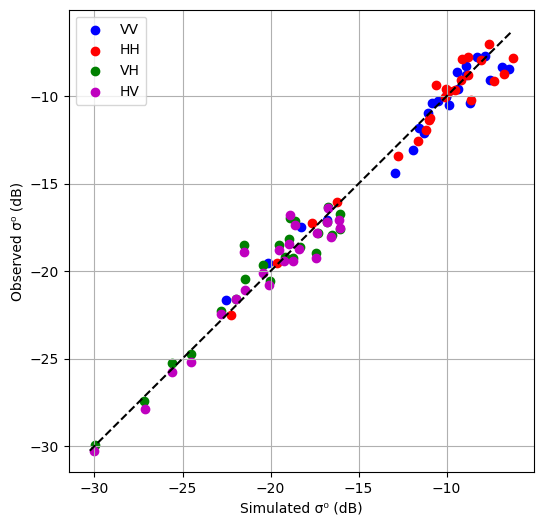

In [33]:
import matplotlib.pyplot as plt
# ==========================================================
# Scatter plot
# ==========================================================
valid_sim_arrays = [np.array(v) for v in sim_all.values() if len(v) > 0]
valid_obs_arrays = [np.array(v) for v in obs_all.values() if len(v) > 0]

if len(valid_sim_arrays) == 0 or len(valid_obs_arrays) == 0:
    print("\nNo valid simulated/observed data found. Skip scatter plot.")
else:
    plt.figure(figsize=(6, 6))

    if len(sim_all["vv"]) > 0:
        plt.scatter(sim_all["vv"], obs_all["vv"], label="VV", c="b")
    if len(sim_all["hh"]) > 0:
        plt.scatter(sim_all["hh"], obs_all["hh"], label="HH", c="r")
    if len(sim_all["vh"]) > 0:
        plt.scatter(sim_all["vh"], obs_all["vh"], label="VH", c="g")
    if len(sim_all["hv"]) > 0:
        plt.scatter(sim_all["hv"], obs_all["hv"], label="HV", c="m")

    all_sim = np.concatenate(valid_sim_arrays)
    all_obs = np.concatenate(valid_obs_arrays)

    minv = min(all_sim.min(), all_obs.min())
    maxv = max(all_sim.max(), all_obs.max())

    plt.plot([minv, maxv], [minv, maxv], "k--")

    plt.xlabel("Simulated σ⁰ (dB)")
    plt.ylabel("Observed σ⁰ (dB)")
    plt.legend()
    plt.grid(True)

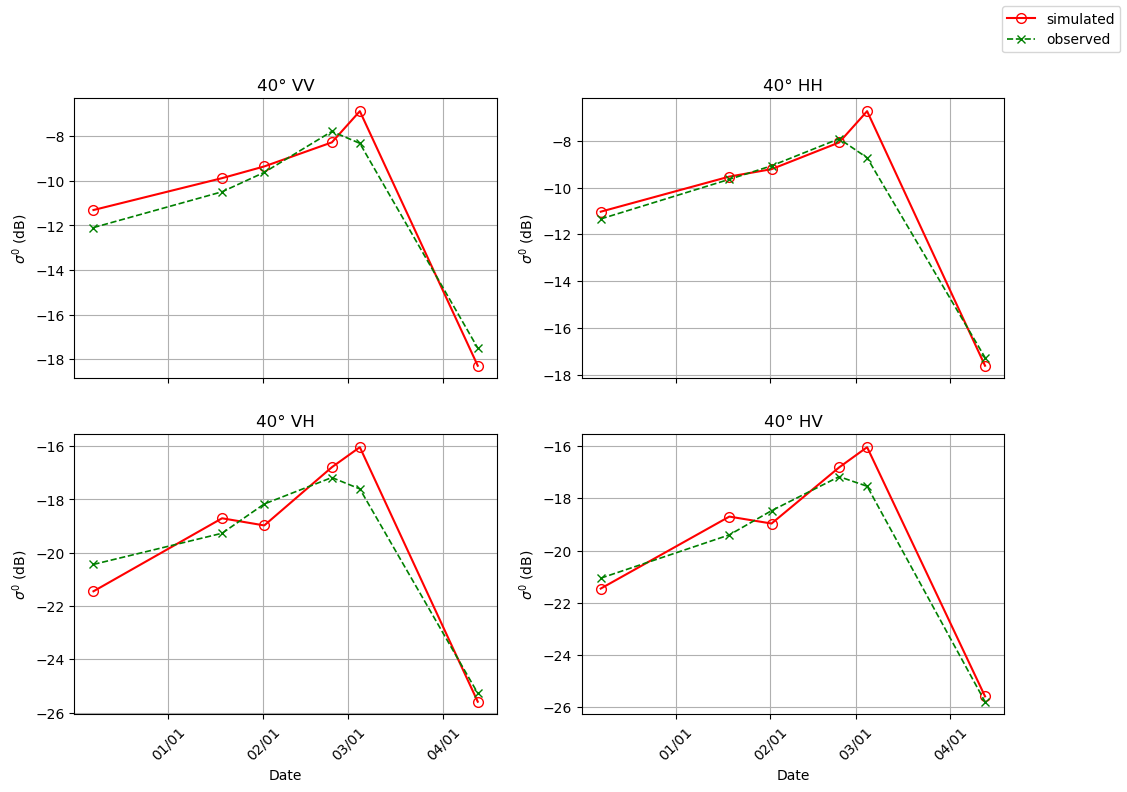

In [34]:
import matplotlib.dates as mdates
# ==========================================================
# Time-series plot for one angle (e.g. 40 degree)
# ==========================================================
# Frequency label for figure title
freq_for_plot = None
pol_list = ["vv", "hh", "vh", "hv"]
pol_title = {"vv": "VV", "hh": "HH", "vh": "VH", "hv": "HV"}

has_ts_data = any(len(ts_data[pol]["time"]) > 0 for pol in pol_list)

if not has_ts_data:
    print(f"No valid time-series data found for {TARGET_ANGLE}°. Skip time-series plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for ax, pol in zip(axes, pol_list):
        if len(ts_data[pol]["time"]) == 0:
            if freq_for_plot is not None:
                ax.set_title(f"{freq_for_plot} GHz {TARGET_ANGLE}° {pol_title[pol]} (No data)")
            else:
                ax.set_title(f"{TARGET_ANGLE}° {pol_title[pol]} (No data)")
            ax.grid(True)
            continue

        # Sort by time to ensure correct line order
        df_pol = pd.DataFrame({
            "time": ts_data[pol]["time"],
            "sim": ts_data[pol]["sim"],
            "obs": ts_data[pol]["obs"],
        }).sort_values("time")

        ax.plot(
            df_pol["time"],
            df_pol["sim"],
            "o-",
            label="simulated",
            linewidth=1.5,
            markersize=7,
            markerfacecolor="none",
            color="red",
        )

        ax.plot(
            df_pol["time"],
            df_pol["obs"],
            "x--",
            label="observed",
            linewidth=1.2,
            markersize=6,
            color="green",
        )

        if freq_for_plot is not None:
            ax.set_title(f"{freq_for_plot} GHz {TARGET_ANGLE}° {pol_title[pol]}")
        else:
            ax.set_title(f"{TARGET_ANGLE}° {pol_title[pol]}")

        ax.set_ylabel(r"$\sigma^0$ (dB)")
        ax.grid(True)

        # Use real datetime axis so spacing follows the actual timeline
        locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
        formatter = mdates.DateFormatter("%m/%d")
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)

    # Bottom row x-label
    axes[2].set_xlabel("Date")
    axes[3].set_xlabel("Date")

    # Rotate x-axis labels
    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

    # Unified legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")